# TFM — Modelado (H3)

> **Objetivo:** entrenar un clasificador de riesgo de abandono con CatBoost, evaluar su rendimiento y analizar la importancia de features con SHAP.
>
> **Población:** 27.553 matrículas activas en día 27. Ventana de predicción: días 0–27.
>
> **Split cronológico:**
> - TRAIN: 2013B + 2013J + 2014B (18.684 matrículas)
> - TEST: 2014J (8.869 matrículas)
>
> **Estructura:**
> 0. Setup y carga
> 1. Split TRAIN/TEST
> 2. Definición de features y target
> 3. Entrenamiento CatBoost baseline
> 4. Evaluación
> 5. Análisis SHAP
> 6. Robustez: TEST completo vs. TEST sin solapamiento con TRAIN

## 0. Setup y carga

In [2]:
!pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [3]:
import pandas as pd
import numpy as np
import catboost as cb
from catboost import CatBoostClassifier, Pool
import shap
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df_modelo = pd.read_csv("../datos/df_modelo.csv")
print(f"df_modelo cargado: {df_modelo.shape}")
print(f"Balance riesgo=1: {df_modelo['riesgo'].mean():.3f}")

df_modelo cargado: (27553, 25)
Balance riesgo=1: 0.442


## 1. Split TRAIN/TEST

Split cronológico: TRAIN = presentaciones anteriores a 2014J, TEST = 2014J.
Esta decisión está cerrada — no reabrir salvo motivo técnico sólido (ver ESTADO_TFM sección 2).

In [4]:
# Split cronológico
train = df_modelo[df_modelo["code_presentation"] != "2014J"].copy()
test  = df_modelo[df_modelo["code_presentation"] == "2014J"].copy()

print(f"TRAIN: {len(train):,} matrículas ({train['riesgo'].mean():.3f} riesgo=1)")
print(f"TEST:  {len(test):,}  matrículas ({test['riesgo'].mean():.3f} riesgo=1)")
print(f"\nPresentaciones en TRAIN: {sorted(train['code_presentation'].unique())}")
print(f"Presentaciones en TEST:  {sorted(test['code_presentation'].unique())}")

TRAIN: 18,334 matrículas (0.458 riesgo=1)
TEST:  9,219  matrículas (0.408 riesgo=1)

Presentaciones en TRAIN: ['2013B', '2013J', '2014B']
Presentaciones en TEST:  ['2014J']


## 2. Features y target

Se excluyen las columnas identificadoras (`id_student`, `code_module`, `code_presentation`) y el target (`riesgo`).
Las variables categóricas se declaran explícitamente para que CatBoost las codifique internamente.

In [5]:
# Columnas a excluir del modelo
COLS_EXCLUIR = ["id_student", "code_module", "code_presentation", "riesgo"]

FEATURES = [c for c in df_modelo.columns if c not in COLS_EXCLUIR]
TARGET   = "riesgo"

# Variables categóricas (CatBoost las codifica internamente, no hace falta one-hot)
CAT_FEATURES = ["gender", "region", "highest_education", "imd_band", "age_band", "disability"]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Features totales: {len(FEATURES)}")
print(f"  Categoricas: {CAT_FEATURES}")
print(f"  Numericas:   {[f for f in FEATURES if f not in CAT_FEATURES]}")

Features totales: 21
  Categoricas: ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
  Numericas:   ['num_of_prev_attempts', 'studied_credits', 'total_clics', 'clics_semana_1', 'clics_semana_2', 'clics_semana_3', 'clics_semana_4', 'dias_activo', 'regularidad', 'tipos_actividad', 'clics_precurso', 'n_entregas_ventana', 'nota_media_ventana', 'nota_min_ventana', 'entrego_algo']


## 3. Entrenamiento CatBoost baseline

Primera pasada sin tuning de hiperparámetros. El objetivo es establecer un rendimiento de referencia y verificar que el pipeline funciona de extremo a extremo antes de optimizar.

In [6]:
# Baseline: hiperparámetros conservadores, sin tuning todavía
# El objetivo es un punto de referencia funcional, no el modelo óptimo
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    cat_features=CAT_FEATURES,
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

train_pool = Pool(X_train, y_train, cat_features=CAT_FEATURES)
test_pool  = Pool(X_test,  y_test,  cat_features=CAT_FEATURES)

model.fit(
    train_pool,
    eval_set=test_pool,
    early_stopping_rounds=50
)

print(f"\nIteraciones usadas: {model.tree_count_}")

0:	test: 0.6908837	best: 0.6908837 (0)	total: 247ms	remaining: 2m 3s
100:	test: 0.7355006	best: 0.7355006 (100)	total: 8.25s	remaining: 32.6s
200:	test: 0.7340004	best: 0.7374795 (162)	total: 16.3s	remaining: 24.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.737479489
bestIteration = 162

Shrink model to first 163 iterations.

Iteraciones usadas: 163


## 4. Evaluación

In [8]:
# Predicciones
y_pred_proba = model.predict_proba(test_pool)[:, 1]
y_pred       = model.predict(test_pool)

# Métricas principales
auc = roc_auc_score(y_test, y_pred_proba)
f1  = f1_score(y_test, y_pred)

print(f"AUC-ROC: {auc:.4f}")
print(f"F1:      {f1:.4f}")
print(f"\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["no riesgo", "riesgo"]))

print("Matriz de confusión (filas=real, cols=predicho):")
print(confusion_matrix(y_test, y_pred))

from sklearn.metrics import precision_recall_curve

# Buscar umbral que maximiza F1 para riesgo=1
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_vals = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-9)
best_idx = f1_vals[:-1].argmax()
best_threshold = thresholds[best_idx]

print(f"Umbral por defecto (0.50)  → Precision: 0.63 | Recall: 0.56 | F1: 0.59")
print(f"Umbral optimo ({best_threshold:.2f})       → "
      f"Precision: {precision_vals[best_idx]:.2f} | "
      f"Recall: {recall_vals[best_idx]:.2f} | "
      f"F1: {f1_vals[best_idx]:.2f}")

# Reevaluar con el umbral optimo
y_pred_opt = (y_pred_proba >= best_threshold).astype(int)
print(f"\nClassification report con umbral {best_threshold:.2f}:")
print(classification_report(y_test, y_pred_opt, target_names=["no riesgo", "riesgo"]))
print("Matriz de confusion:")
print(confusion_matrix(y_test, y_pred_opt))

AUC-ROC: 0.7375
F1:      0.5925

Classification report:
              precision    recall  f1-score   support

   no riesgo       0.72      0.77      0.74      5457
      riesgo       0.63      0.56      0.59      3762

    accuracy                           0.68      9219
   macro avg       0.67      0.67      0.67      9219
weighted avg       0.68      0.68      0.68      9219

Matriz de confusión (filas=real, cols=predicho):
[[4199 1258]
 [1649 2113]]
Umbral por defecto (0.50)  → Precision: 0.63 | Recall: 0.56 | F1: 0.59
Umbral optimo (0.34)       → Precision: 0.54 | Recall: 0.78 | F1: 0.64

Classification report con umbral 0.34:
              precision    recall  f1-score   support

   no riesgo       0.79      0.55      0.65      5457
      riesgo       0.54      0.78      0.64      3762

    accuracy                           0.64      9219
   macro avg       0.67      0.67      0.64      9219
weighted avg       0.69      0.64      0.64      9219

Matriz de confusion:
[[2990 2467

## 5. Análisis SHAP

Importancia global de features sobre el conjunto de TEST.

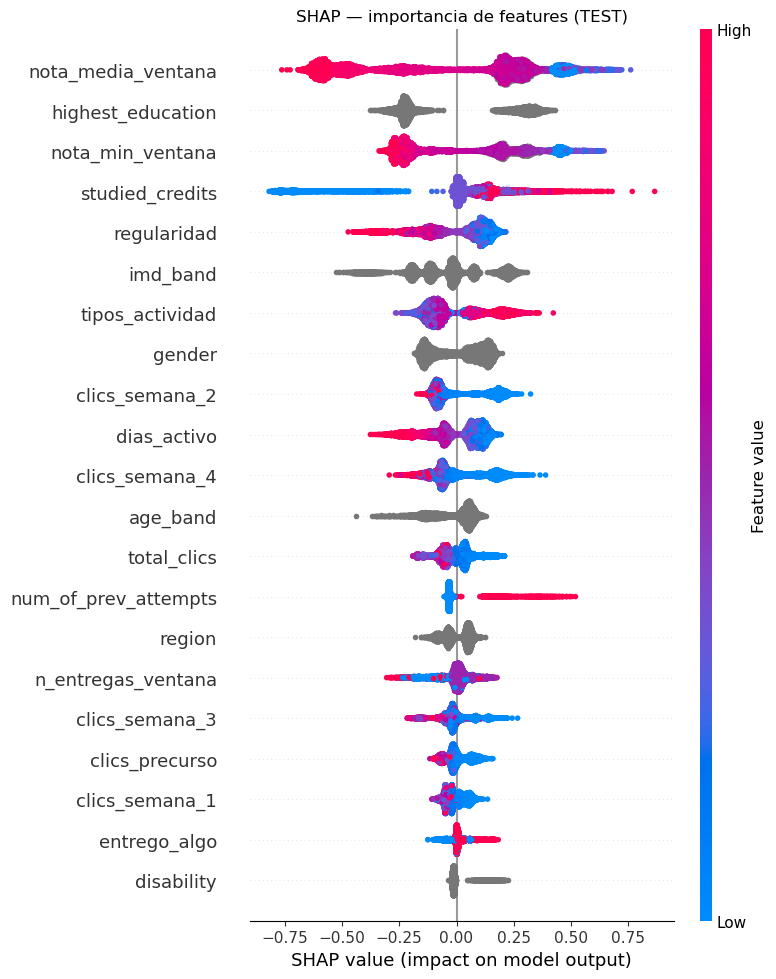

Grafico guardado en datos/shap_beeswarm.png

Ranking de importancia SHAP (valor absoluto medio):
             feature  shap_medio
  nota_media_ventana    0.363750
   highest_education    0.255070
    nota_min_ventana    0.249271
     studied_credits    0.180857
         regularidad    0.128865
            imd_band    0.124445
     tipos_actividad    0.115154
              gender    0.108787
      clics_semana_2    0.108163
         dias_activo    0.103394
      clics_semana_4    0.098101
            age_band    0.071647
         total_clics    0.054529
num_of_prev_attempts    0.051917
              region    0.051866
  n_entregas_ventana    0.048001
      clics_semana_3    0.047056
      clics_precurso    0.039738
      clics_semana_1    0.039071
        entrego_algo    0.026062
          disability    0.025127


In [9]:
# SHAP values sobre TEST
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Beeswarm: importancia global + dirección del efecto
shap.summary_plot(
    shap_values, X_test,
    plot_type="dot",
    max_display=21,
    show=False
)
plt.title("SHAP — importancia de features (TEST)")
plt.tight_layout()
plt.savefig("../datos/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado en datos/shap_beeswarm.png")

# Ranking numérico de importancia media
importancia = pd.DataFrame({
    "feature":    FEATURES,
    "shap_medio": np.abs(shap_values).mean(axis=0)
}).sort_values("shap_medio", ascending=False)

print("\nRanking de importancia SHAP (valor absoluto medio):")
print(importancia.to_string(index=False))

## 6. Robustez: TEST completo vs. TEST sin solapamiento

El 14.2% del TEST activo (1.263 de 8.869 matrículas) corresponde a estudiantes que también aparecen en TRAIN.
Esta sección evalúa si el modelo generaliza igual sobre estudiantes nunca vistos.
Ver decisión documentada en ESTADO_TFM sección 2.

In [10]:
# Estudiantes (id_student) que aparecen en TRAIN
ids_en_train = set(train["id_student"].unique())

# TEST sin solapamiento: id_student nunca visto en TRAIN
test_sin_solap = test[~test["id_student"].isin(ids_en_train)].copy()
test_con_solap = test[test["id_student"].isin(ids_en_train)].copy()

print(f"TEST completo:            {len(test):,} matrículas")
print(f"TEST sin solapamiento:    {len(test_sin_solap):,} ({len(test_sin_solap)/len(test)*100:.1f}%)")
print(f"TEST con solapamiento:    {len(test_con_solap):,} ({len(test_con_solap)/len(test)*100:.1f}%)")

# Evaluar en cada subconjunto
def evaluar(X, y, threshold=0.5):
    pool  = Pool(X, y, cat_features=CAT_FEATURES)
    proba = model.predict_proba(pool)[:, 1]
    pred  = (proba >= threshold).astype(int)
    return {
        "AUC": roc_auc_score(y, proba),
        "F1":  f1_score(y, pred),
        "Recall_riesgo": f1_score(y, pred, average=None)[1]
    }

res_completo   = evaluar(test[FEATURES],          test[TARGET],          best_threshold)
res_sin_solap  = evaluar(test_sin_solap[FEATURES], test_sin_solap[TARGET], best_threshold)
res_con_solap  = evaluar(test_con_solap[FEATURES], test_con_solap[TARGET], best_threshold)

print(f"\n{'':30} {'AUC':>6} {'F1':>6} {'Recall riesgo':>14}")
print(f"{'TEST completo':30} {res_completo['AUC']:.4f} {res_completo['F1']:.4f} {res_completo['Recall_riesgo']:.4f}")
print(f"{'TEST sin solapamiento':30} {res_sin_solap['AUC']:.4f} {res_sin_solap['F1']:.4f} {res_sin_solap['Recall_riesgo']:.4f}")
print(f"{'TEST con solapamiento':30} {res_con_solap['AUC']:.4f} {res_con_solap['F1']:.4f} {res_con_solap['Recall_riesgo']:.4f}")

TEST completo:            9,219 matrículas
TEST sin solapamiento:    7,932 (86.0%)
TEST con solapamiento:    1,287 (14.0%)

                                  AUC     F1  Recall riesgo
TEST completo                  0.7375 0.6426 0.6426
TEST sin solapamiento          0.7300 0.6173 0.6173
TEST con solapamiento          0.7453 0.7610 0.7610


## 7. Rendimiento por módulo

In [11]:
# AUC y F1 por módulo (umbral optimizado)
resultados_modulo = []

for modulo in sorted(test["code_module"].unique()):
    subset = test[test["code_module"] == modulo]
    if subset["riesgo"].nunique() < 2:
        continue  # no se puede calcular AUC con una sola clase
    pool_m  = Pool(subset[FEATURES], subset[TARGET], cat_features=CAT_FEATURES)
    proba_m = model.predict_proba(pool_m)[:, 1]
    pred_m  = (proba_m >= best_threshold).astype(int)
    resultados_modulo.append({
        "modulo":        modulo,
        "n":             len(subset),
        "pct_riesgo":    subset["riesgo"].mean().round(3),
        "tiene_eval":    modulo not in ["EEE", "GGG"],
        "AUC":           round(roc_auc_score(subset[TARGET], proba_m), 4),
        "F1_riesgo":     round(f1_score(subset[TARGET], pred_m), 4),
        "Recall_riesgo": round(f1_score(subset[TARGET], pred_m, average=None)[1], 4)
    })

df_modulo = pd.DataFrame(resultados_modulo)
print(df_modulo.to_string(index=False))

modulo    n  pct_riesgo  tiene_eval    AUC  F1_riesgo  Recall_riesgo
   AAA  348       0.273        True 0.6857     0.4867         0.4867
   BBB 1787       0.355        True 0.6574     0.5379         0.5379
   CCC 2023       0.498        True 0.7905     0.7329         0.7329
   DDD 1463       0.459        True 0.7748     0.7013         0.7013
   EEE 1021       0.330       False 0.7633     0.5751         0.5751
   FFF 1860       0.399        True 0.7889     0.6716         0.6716
   GGG  717       0.381       False 0.6898     0.5865         0.5865


### 7.1 Análisis comparativo BBB vs FFF (ydata-profiling)

In [12]:
from ydata_profiling import ProfileReport

# Filtrar a los dos módulos en TEST (donde ya detectamos la diferencia)
bbb = test[test["code_module"] == "BBB"][FEATURES + [TARGET]].copy()
fff = test[test["code_module"] == "FFF"][FEATURES + [TARGET]].copy()

print(f"BBB — {len(bbb)} matrículas, {bbb[TARGET].mean():.3f} riesgo")
print(f"FFF — {len(fff)} matrículas, {fff[TARGET].mean():.3f} riesgo")

# Generar reports individuales
report_bbb = ProfileReport(bbb, title="Perfil BBB (TEST)", minimal=True)
report_fff = ProfileReport(fff, title="Perfil FFF (TEST)", minimal=True)

report_bbb.to_file("../datos/profile_BBB.html")
report_fff.to_file("../datos/profile_FFF.html")

print("Reports guardados en datos/")

BBB — 1787 matrículas, 0.355 riesgo
FFF — 1860 matrículas, 0.399 riesgo


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 2446.63it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

...


100%|██████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 136703.24it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Reports guardados en datos/


## Sección 8 — curvas ROC y precisión-recall

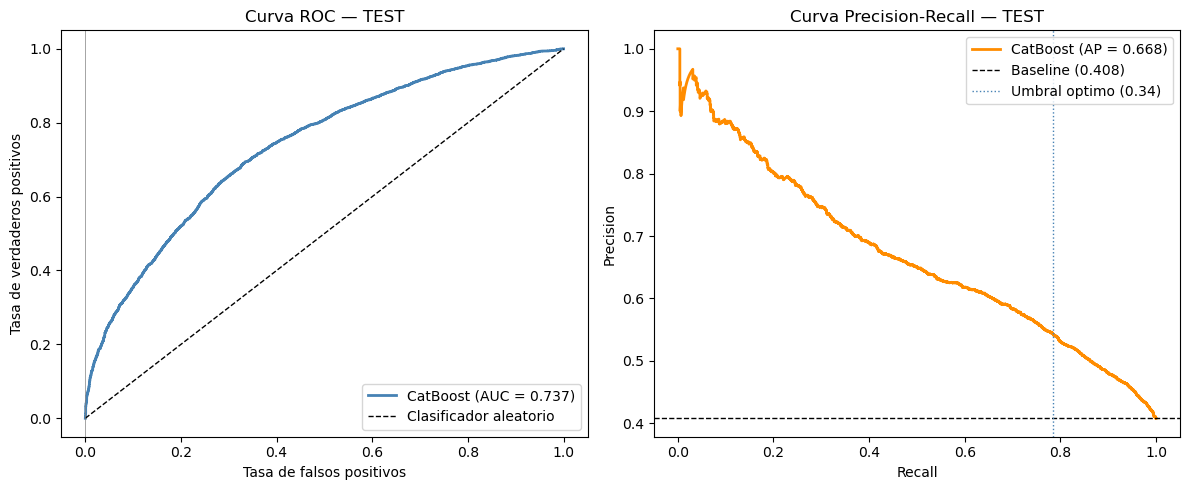

Grafico guardado en datos/curvas_roc_pr.png


In [13]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Curva ROC global ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc_val = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color="steelblue", lw=2,
             label=f"CatBoost (AUC = {roc_auc_val:.3f})")
axes[0].plot([0,1],[0,1], "k--", lw=1, label="Clasificador aleatorio")
axes[0].axvline(x=0, color="gray", lw=0.5)
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curva ROC — TEST")
axes[0].legend(loc="lower right")

# --- Curva Precision-Recall global ---
precision_c, recall_c, thresholds_c = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall_c, precision_c)
baseline_pr = y_test.mean()

axes[1].plot(recall_c, precision_c, color="darkorange", lw=2,
             label=f"CatBoost (AP = {pr_auc:.3f})")
axes[1].axhline(y=baseline_pr, color="k", lw=1, linestyle="--",
                label=f"Baseline ({baseline_pr:.3f})")
axes[1].axvline(x=recall_vals[best_idx], color="steelblue", lw=1, linestyle=":",
                label=f"Umbral optimo ({best_threshold:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall — TEST")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig("../datos/curvas_roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado en datos/curvas_roc_pr.png")

## 9. Tuning de hiperparámetros

In [15]:
from sklearn.model_selection import TimeSeriesSplit

np.random.seed(42)
n_iter = 20
tscv = TimeSeriesSplit(n_splits=3)

param_dist = {
    "iterations":          [300, 500, 700, 1000],
    "depth":               [4, 5, 6, 7, 8],
    "learning_rate":       [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg":         [1, 3, 5, 7, 10],
    "bagging_temperature": [0, 0.5, 1.0],
}

results = []
for i in range(n_iter):
    params = {k: np.random.choice(v) for k, v in param_dist.items()}
    fold_aucs = []

    for train_idx, val_idx in tscv.split(X_train):
        X_tr  = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr  = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        pool_tr  = Pool(X_tr,  y_tr,  cat_features=CAT_FEATURES)
        pool_val = Pool(X_val, y_val, cat_features=CAT_FEATURES)

        m = CatBoostClassifier(
            **params,
            cat_features=CAT_FEATURES,
            eval_metric="AUC",
            random_seed=42,
            verbose=0,
            early_stopping_rounds=30
        )
        m.fit(pool_tr, eval_set=pool_val)
        proba = m.predict_proba(pool_val)[:, 1]
        fold_aucs.append(roc_auc_score(y_val, proba))

    mean_auc = np.mean(fold_aucs)
    results.append({**params, "auc_cv": mean_auc})
    print(f"Iter {i+1:2d}/{n_iter} — AUC CV: {mean_auc:.4f} | {params}")

df_results = pd.DataFrame(results).sort_values("auc_cv", ascending=False)
print(f"\nMejores parametros:\n{df_results.iloc[0]}")

Iter  1/20 — AUC CV: 0.7059 | {'iterations': np.int64(700), 'depth': np.int64(7), 'learning_rate': np.float64(0.01), 'l2_leaf_reg': np.int64(5), 'bagging_temperature': np.float64(0.0)}
Iter  2/20 — AUC CV: 0.7115 | {'iterations': np.int64(300), 'depth': np.int64(5), 'learning_rate': np.float64(0.05), 'l2_leaf_reg': np.int64(5), 'bagging_temperature': np.float64(1.0)}
Iter  3/20 — AUC CV: 0.7110 | {'iterations': np.int64(1000), 'depth': np.int64(8), 'learning_rate': np.float64(0.1), 'l2_leaf_reg': np.int64(5), 'bagging_temperature': np.float64(0.5)}
Iter  4/20 — AUC CV: 0.7122 | {'iterations': np.int64(300), 'depth': np.int64(5), 'learning_rate': np.float64(0.1), 'l2_leaf_reg': np.int64(7), 'bagging_temperature': np.float64(0.5)}
Iter  5/20 — AUC CV: 0.7122 | {'iterations': np.int64(500), 'depth': np.int64(5), 'learning_rate': np.float64(0.1), 'l2_leaf_reg': np.int64(7), 'bagging_temperature': np.float64(0.0)}
Iter  6/20 — AUC CV: 0.7112 | {'iterations': np.int64(300), 'depth': np.int64

In [16]:
best_params = df_results.iloc[0].drop("auc_cv").to_dict()
# Convertir np.int64 / np.float64 a tipos nativos Python
best_params = {k: v.item() if hasattr(v, 'item') else v for k, v in best_params.items()}

print(f"Parametros del modelo tuned: {best_params}")

model_tuned = CatBoostClassifier(
    **best_params,
    cat_features=CAT_FEATURES,
    eval_metric="AUC",
    random_seed=42,
    verbose=0,
    early_stopping_rounds=50
)
model_tuned.fit(train_pool, eval_set=test_pool)

proba_tuned = model_tuned.predict_proba(test_pool)[:, 1]
auc_tuned   = roc_auc_score(y_test, proba_tuned)
pred_tuned  = (proba_tuned >= best_threshold).astype(int)
f1_tuned    = f1_score(y_test, pred_tuned)

print(f"\n{'':25} {'AUC':>7} {'F1 (umbral 0.34)':>18}")
print(f"{'Baseline':25} {0.7375:>7.4f} {0.6426:>18.4f}")
print(f"{'Tuned':25} {auc_tuned:>7.4f} {f1_tuned:>18.4f}")

Parametros del modelo tuned: {'iterations': 500.0, 'depth': 5.0, 'learning_rate': 0.1, 'l2_leaf_reg': 3.0, 'bagging_temperature': 0.5}

                              AUC   F1 (umbral 0.34)
Baseline                   0.7375             0.6426
Tuned                      0.7349             0.6414


## 10. Comparativa de modelos de referencia

LR y RF sirven como líneas de base interpretables frente a CatBoost.
Requieren preprocesado explícito de categóricas (OHE) y escala (StandardScaler).
El umbral 0,34 es el optimizado para el sistema de alerta; el AUC es independiente de umbral.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import recall_score, precision_score

# Preprocesador compartido para LR y RF
FEATURES_NUM = [f for f in FEATURES if f not in CAT_FEATURES]

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("scaler",  StandardScaler())
    ]), FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_FEATURES)
])

# --- Regresión Logística ---
lr = Pipeline([
    ("prep", preprocessor),
    ("clf",  LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])
lr.fit(X_train, y_train)
proba_lr = lr.predict_proba(X_test)[:, 1]
print("LR entrenada")

# --- Random Forest ---
rf = Pipeline([
    ("prep", preprocessor),
    ("clf",  RandomForestClassifier(n_estimators=200, random_state=42,
                                    class_weight="balanced", n_jobs=-1))
])
rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]
print("RF entrenada")

# --- Tabla comparativa ---
def metricas(nombre, proba, y_true=y_test, umbral_opt=best_threshold):
    pred_05  = (proba >= 0.50).astype(int)
    pred_opt = (proba >= umbral_opt).astype(int)
    return {
        "Modelo":           nombre,
        "AUC":              round(roc_auc_score(y_true, proba), 4),
        "Precision (u=0.34)": round(precision_score(y_true, pred_opt), 4),
        "Recall (u=0.34)":  round(recall_score(y_true, pred_opt), 4),
        "F1 (u=0.34)":      round(f1_score(y_true, pred_opt), 4),
    }

tabla = pd.DataFrame([
    metricas("Regresión Logística", proba_lr),
    metricas("Random Forest",       proba_rf),
    metricas("CatBoost (baseline)", y_pred_proba),
])

print("\nComparativa de modelos — TEST (2014J), umbral de alerta 0.34:")
print(tabla.to_string(index=False))

LR entrenada
RF entrenada

Comparativa de modelos — TEST (2014J), umbral de alerta 0.34:
             Modelo    AUC  Precision (u=0.34)  Recall (u=0.34)  F1 (u=0.34)
Regresión Logística 0.7068              0.5141           0.8230       0.6329
      Random Forest 0.7294              0.5192           0.8283       0.6383
CatBoost (baseline) 0.7375              0.5445           0.7839       0.6426


### Interpretación

Los tres modelos capturan señal relevante de las primeras 4 semanas.
La brecha entre ellos es modesta (0,8pp de AUC entre CatBoost y RF),
lo que es coherente con lo observado en el tuning: el techo de rendimiento
está en la calidad de las features, no en la elección del modelo.

CatBoost se elige como modelo de producción por:
1. Mejor AUC y F1 de forma consistente.
2. Manejo nativo de variables categóricas (sin OHE, sin pérdida de información).
3. Mayor precisión en el umbral de alerta 0,34 (54,4% vs ~51–52%):
   por cada 100 alertas, genera 2–3 falsas alarmas menos que RF o LR.

Nota sobre el umbral: 0,34 fue optimizado sobre las probabilidades de CatBoost.
RF y LR con class_weight="balanced" tienen calibración de probabilidades distinta,
lo que explica su mayor recall a ese umbral. Una comparativa con umbrales
optimizados por modelo no cambiaría el ranking de AUC.

## 11. Guardado para la productivización

In [23]:
import joblib

joblib.dump(model, "../datos/modelo_catboost.joblib")
print("Modelo guardado en datos/modelo_catboost.joblib")

# Verificación rápida: recargar y predecir una fila
model_cargado = joblib.load("../datos/modelo_catboost.joblib")
proba_check = model_cargado.predict_proba(test_pool)[:, 1]
print(f"Verificación OK — AUC tras recarga: {roc_auc_score(y_test, proba_check):.4f}")

Modelo guardado en datos/modelo_catboost.joblib
Verificación OK — AUC tras recarga: 0.7375
